## *Semana 3: Fundamentos estadísticos y optimización*

## 4.2. Explorando el problema: ¿qué infuye en la matrícula de cada semestre?

In [1]:
import numpy as np #importa la libreria NumPy para calculos numericos 
import pandas as pd #Importa pandas para manipular una estructura de datos
import matplotlib.pyplot as plt #Importa PyPlot de Matplotlib para la creación de gráficos y visualizaciones
from sklearn.linear_model import LinearRegression #Importa la clase de Regresión Lineal

matricula = pd.read_csv("matricula_sistemas.csv") #Lee el archivo CSV y carga el contenido
matricula.describe() #Calcula estadísticas descriptivas generales de todas las columnas numericas

,num_postulantes,becas_otorgadas,tasa_desercion_anterior,campania_difusion,num_matriculados
count,24.000000,24.000000,24.000000,24.000000,24.000000
mean,231.125000,18.250000,0.129917,0.500000,137.083333
std,41.277757,6.917212,0.021055,0.510754,34.122435
min,146.000000,8.000000,0.096000,0.000000,75.000000
25%,200.250000,12.750000,0.110750,0.000000,111.500000
50%,222.500000,17.500000,0.127500,0.500000,137.000000
75%,261.250000,24.250000,0.150250,1.000000,161.500000
max,311.000000,30.000000,0.167000,1.000000,198.000000


# Parte B ¿Cuántos alumnos se matriculan en promedio? ¿qué tan dispersa es esa cifra de un semestre a otro? Calcular los estadísticos descriptivos de num_matriculados:

In [3]:
col = matricula["num_matriculados"] #Selecciona la columna de la variable objetivo
print("Media:", col.mean()) #Calcula e imprime la media aritmética (promedio de matriculados por semestre)
print("Mediana:", col.median()) #Calcula e imprime la mediana (el valor central al ordenar los datos)
print("Moda:", col.mode().tolist()) #Encuentra el valor o valores que más se repiten y los convierte en una lista
print("Rango:", col.max() - col.min()) #Calcula la diferencia entre el valor máximo y el valor mínimo
print("Varianza:", col.var()) #Calcula la varianza muestral (grado de dispersión al cuadrado)
print("Desviacion estandar:", col.std()) #Calcula la desviación estándar muestral (dispersión en la misma unidad que los datos)

Media: 137.08333333333334
Mediana: 137.0
Moda: [120, 137, 160]
Rango: 123
Varianza: 1164.340579710145
Desviacion estandar: 34.12243513745971


# Parte C: Calcular la correlación de cada variable contra num_matriculados, para decidir cuáles conviene usar para predecirla::

In [4]:
matricula.corr(numeric_only=True)["num_matriculados"] #Calcula la matriz de correlación de Pearson entre todas las variables numéricas del dataset
#con ["num_matriculados"] filtramos el resultado para visualizar solo la correlación de cada variable respecto a la matrícula.

num_postulantes            0.951145
becas_otorgadas            0.895512
tasa_desercion_anterior   -0.436143
campania_difusion          0.496448
num_matriculados           1.000000
Name: num_matriculados, dtype: float64

**¿Cuál variable está más fuertemente correlacionada con la matrícula?** 
La variable num_postulantes es quien presenta el coeficiente de correlacion positiva mas cercana a 1

**¿Cuál aporta menos?**
La variable con coeficiente mas cercano a 0 como tasa_desercion_anterior o campania_difusion.

## 4.3. Visualizando la función de error de un modelo real

In [5]:
postulantes = matricula["num_postulantes"] #Extrae la columna del número de postulantes
postulantes_norm = (postulantes - postulantes.mean()) / postulantes.std() #Normaliza la variable aplicando estandarización Z-score
matriculados = matricula["num_matriculados"].astype(float) #Convierte los valores de la variable de matriculados al tipo numérico decimal

**Parte A: Graficar el error cuadrático medio (MSE) en función de la pendiente w, dejando el
intercepto fijo en b = 137.1 (su valor óptimo, ya calculado), para ver visualmente dónde está el
mínimo:**

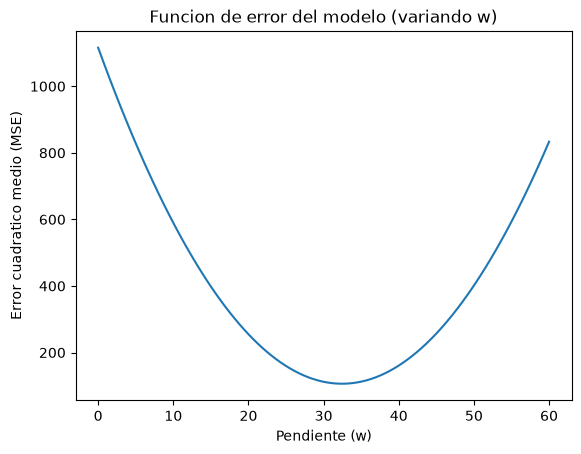

In [6]:
b_fijo = 137.1 #Establece un valor constante óptimo para el intercepto $b$.
valores_w = np.linspace(0, 60, 100) #Crea 100 puntos distribuidos uniformemente entre 0 y 60 para evaluar diferentes valores de la pendiente $w$.
errores = [] #Crea una lista vacía para guardar los valores de error calculados

for w in valores_w: #Bucle que itera sobre cada valor candidato de $w$. 
    prediccion = w * postulantes_norm + b_fijo #Genera las predicciones de la ecuación lineal
    mse = np.mean((prediccion - matriculados) ** 2) # Calcula el Error Cuadrático Medio
    errores.append(mse) #Añade el resultado del MSE a la lista de errores
    
plt.plot(valores_w, errores) #Dibuja la parábola curva del error en función de la pendiente $w$. 
plt.xlabel("Pendiente (w)") #Define el texto del eje X
plt.ylabel("Error cuadratico medio (MSE)") #Define el texto del eje Y
plt.title("Funcion de error del modelo (variando w)") #Establece el título del gráfico
plt.show() #Despliega la figura generada

## 4.4. Descenso de gradiente: cómo se entrena un modelo, paso a paso

In [8]:
w, b = 0.0, 0.0 # Inicializa los parámetros del modelo en $0.0$
tasa_aprendizaje = 0.3 # Asigna la hiperparámetro de tasa de aprendizaje $\alpha = 0.3$
n = len(postulantes_norm) # Obtiene la cantidad de datos n(n = 24)

for paso in range(1, 11): #Bucle que realiza 10 iteraciones del algoritmo
    prediccion = w * postulantes_norm + b #Estima los valores de la variable dependiente.
    error = prediccion - matriculados #Calcula la diferencia/residuo entre la estimación y el valor real
    mse = np.mean(error ** 2) #Obtiene el costo cuadrático medio de la iteración actual.
    
    gradiente_w = (2 / n) * np.sum(error * postulantes_norm) #Calcula la derivada parcial de la función de costo con respecto a w.
    gradiente_b = (2 / n) * np.sum(error) #Calcula la derivada parcial con respecto a b. 
    
    w = w - tasa_aprendizaje * gradiente_w #Actualiza la pendiente w dando un paso en sentido opuesto al gradiente
    b = b - tasa_aprendizaje * gradiente_b #Actualiza el intercepto b dando un paso en sentido opuesto al gradiente.
    
    print(f"Paso {paso}: MSE={mse:.2f} w={w} b={b}") #Muestra en consola la evolución del MSE, w y b paso a paso

Paso 1: MSE=19907.67 w=18.661836238544765 b=82.24999999999999
Paso 2: MSE=3295.39 w=26.593116639926293 b=115.14999999999999
Paso 3: MSE=620.37 w=29.96391081051344 b=128.31
Paso 4: MSE=189.29 w=31.39649833301298 b=133.574
Paso 5: MSE=119.76 w=32.00534803007528 b=135.6796
Paso 6: MSE=108.53 w=32.264109151326764 b=136.52184
Paso 7: MSE=106.72 w=32.37408262785864 b=136.858736
Paso 8: MSE=106.42 w=32.42082135538469 b=136.9934944
Paso 9: MSE=106.37 w=32.440685314583256 b=137.04739776
Paso 10: MSE=106.37 w=32.44912749724265 b=137.068959104


**Comprobación con Scikit-Learn:**

In [10]:
X_simple = postulantes_norm.values.reshape(-1, 1) #Convierte el vector en una matriz de 2 dimensiones requerida por Scikit-Learn
comprobacion = LinearRegression().fit(X_simple, matriculados) #Instancia y entrena el modelo de Regresión Lineal
w_sk = round(comprobacion.coef_[0], 2) # Obtiene el coeficiente de pendiente ajustado redondeado a 2 decimales
b_sk = round(comprobacion.intercept_, 2) # Obtiene el intercepto ajustado redondeado a 2 decimales
print("Scikit-learn: w =", w_sk, " b =", b_sk) # Muestra los coeficientes óptimos analíticos

Scikit-learn: w = 32.46  b = 137.08
